In [1]:
import sys
sys.path.append('../')
from PreprocessorsObjects import CyclicalScalling
import pandas as pd
from IPython.display import clear_output
import matplotlib.pyplot as plt
import matplotlib

In [2]:
%pip install huggingface_hub --user
clear_output()

In [3]:
df = pd.read_csv("hf://datasets/CitrusBoy/EnergyPriceForecasting/final_dataset_full_clean_with_gas_no_processing.csv")
df["time"] = pd.to_datetime(df["time"])

/home/citrusboy/Documents/OpenRemote-Energy-Forecasting/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Cyclical Scalling

In [4]:
df_transformed = CyclicalScalling().transform(df, drop=False)


<>:11: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
<>:12: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
<>:11: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
<>:12: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
/tmp/ipykernel_8377/3281496431.py:11: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
  xlabel="sin(day\_of\_week)",
/tmp/ipykernel_8377/3281496431.py:12: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is

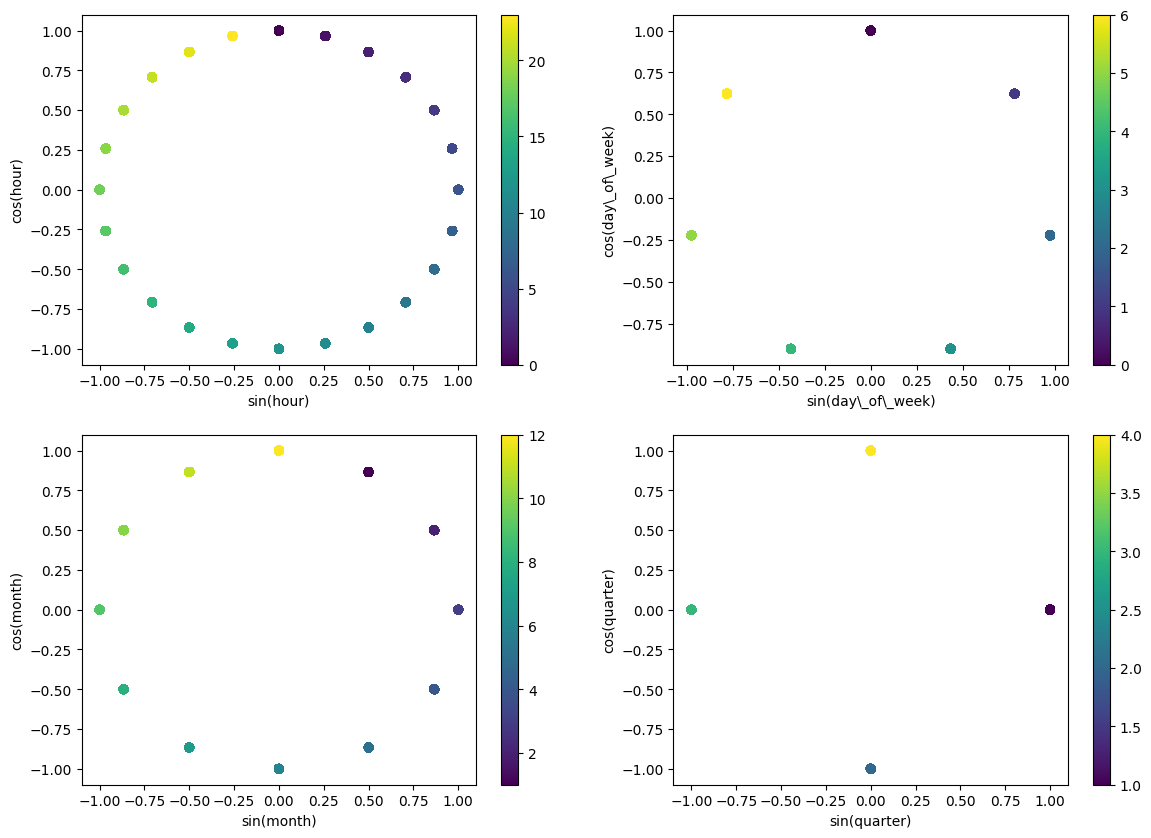

In [5]:
fig, ax = plt.subplots(2,2,figsize=(14, 10))
sp =ax[0,0].scatter(df_transformed["hour_sin"], df_transformed["hour_cos"], c=df_transformed["hour"], rasterized=True)
ax[0,0].set(
    xlabel="sin(hour)",
    ylabel="cos(hour)"
)
_ = fig.colorbar(sp)

sp = ax[0,1].scatter(df_transformed["day_of_week_sin"], df_transformed["day_of_week_cos"], c=df_transformed["day_of_week"], rasterized=True)
ax[0,1].set(
    xlabel="sin(day\_of\_week)",
    ylabel="cos(day\_of\_week)"
)
_ = fig.colorbar(sp)
sp = ax[1,0].scatter(df_transformed["month_sin"], df_transformed["month_cos"], c=df_transformed["month"], rasterized=True)
ax[1,0].set(
    xlabel="sin(month)",
    ylabel="cos(month)"
)
_ = fig.colorbar(sp)

sp = ax[1,1].scatter(df_transformed["quarter_sin"], df_transformed["quarter_cos"], c=df_transformed["quarter"], rasterized=True)
ax[1,1].set(
    xlabel="sin(quarter)",
    ylabel="cos(quarter)"
)
_ = fig.colorbar(sp)

In [6]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'sans-serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
})


In [7]:
fig.savefig("cyclicalScallingFig.pgf", bbox_inches="tight")

## A Bit of an Explanation

This is **one** of the valid methods for processing date and time columns for time-series data. Consider others when choosing what to do with them.

This particular method provides cyclicality to time. Like how months, weekdays and hours are not linear but cyclical; they "reset" on every cycle. This method hightlights that property. Thusly, we extract more features out of the original date.